In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

# Check for Apple Silicon GPU (MPS) support
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Define base hyperparameters
sequence_length = 28
input_size = 28
batch_size = 64
num_epochs = 5

Using device: mps


In [2]:
# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST (10 classes: Digits 0-9)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

mnist_train_loader = DataLoader(dataset=mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(dataset=mnist_test, batch_size=batch_size, shuffle=False)

# Load EMNIST (Example: Letters with 26 classes)
emnist_train = torchvision.datasets.EMNIST(root='./data', split='letters', train=True, transform=transform, download=True)
emnist_test = torchvision.datasets.EMNIST(root='./data', split='letters', train=False, transform=transform, download=True)

emnist_train_loader = DataLoader(dataset=emnist_train, batch_size=batch_size, shuffle=True)
emnist_test_loader = DataLoader(dataset=emnist_test, batch_size=batch_size, shuffle=False)

print(f"MNIST Training Samples: {len(mnist_train)}")
print(f"EMNIST Letters Training Samples: {len(emnist_train)}")

100.0%
100.0%
100.0%
100.0%
100.0%


MNIST Training Samples: 60000
EMNIST Letters Training Samples: 124800


In [4]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, h0)
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

In [11]:
# Insert after VanillaRNN cell
class RNNFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(RNNFromScratch, self).__init__()
        self.hidden_size = hidden_size
        
        # Weights for input to hidden
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.01)
        # Weights for hidden to hidden
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        # Bias for hidden state
        self.b_h = nn.Parameter(torch.zeros(1, hidden_size))
        
        # Weights for hidden to output
        self.W_hy = nn.Parameter(torch.randn(hidden_size, num_classes) * 0.01)
        self.b_y = nn.Parameter(torch.zeros(1, num_classes))

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # Process sequence step-by-step
        for t in range(seq_len):
            x_t = x[:, t, :]
            # h_t = tanh(x_t * W_xh + h_{t-1} * W_hh + b_h)
            h_t = torch.tanh(torch.matmul(x_t, self.W_xh) + torch.matmul(h_t, self.W_hh) + self.b_h)
            
        # Output calculation based on the last hidden state
        out = torch.matmul(h_t, self.W_hy) + self.b_y
        return out

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [6]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [7]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        # Multiply hidden_size by 2 because it's bidirectional
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [12]:
# Insert after BiLSTMModel cell
class BiGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiGRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        # Multiply hidden_size by 2 for bidirectional
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [8]:
class CNNLSTMHybrid(nn.Module):
    def __init__(self, hidden_size, num_layers, num_classes):
        super(CNNLSTMHybrid, self).__init__()
        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=28, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # LSTM processes the extracted sequence
        # After MaxPool1d, the sequence length drops from 28 to 14
        self.lstm = nn.LSTM(input_size=14, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x is (batch, 28, 28). Treat 2nd dim as channels for Conv1d
        x = self.cnn(x) 
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [13]:
# Insert after CNNLSTMHybrid cell
class TimeDistributedCNNLSTM(nn.Module):
    def __init__(self, hidden_size, num_layers, num_classes):
        super(TimeDistributedCNNLSTM, self).__init__()
        # CNN to process each row (time step) individually
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # After max pooling, a 28-length row becomes 14 features * 16 channels = 224
        self.lstm = nn.LSTM(input_size=224, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, seq_len, features = x.size()
        # Reshape for CNN: Combine batch and seq_len, add channel dim
        # (batch_size * seq_len, 1 channel, features)
        x_reshaped = x.view(batch_size * seq_len, 1, features)
        
        cnn_out = self.cnn(x_reshaped)
        # Flatten CNN output
        cnn_out = cnn_out.view(batch_size, seq_len, -1) 
        
        out, _ = self.lstm(cnn_out)
        out = self.fc(out[:, -1, :])
        return out

In [9]:
def train_and_evaluate(model, train_loader, test_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    grad_magnitudes = [] # To analyze vanishing gradients
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for i, (images, labels) in enumerate(train_loader):
            # Reshape images to (batch_size, sequence_length, input_size)
            images = images.squeeze(1).to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Track gradient norms for layer 1 to analyze vanishing gradients
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1. / 2)
            grad_magnitudes.append(total_norm)
            
            optimizer.step()
            epoch_loss += loss.item()
            
        train_losses.append(epoch_loss / len(train_loader))
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}")
        
    train_time = time.time() - start_time
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.squeeze(1).to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    
    # Calculate parameter count
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    return accuracy, train_time, train_losses, grad_magnitudes, param_count


----------------------------------------
Training Vanilla RNN (PyTorch)...
----------------------------------------
Epoch [1/3], Loss: 0.6333
Epoch [2/3], Loss: 0.2676
Epoch [3/3], Loss: 0.2127
Test Accuracy: 93.64%, Time: 72.13s, Params: 54538


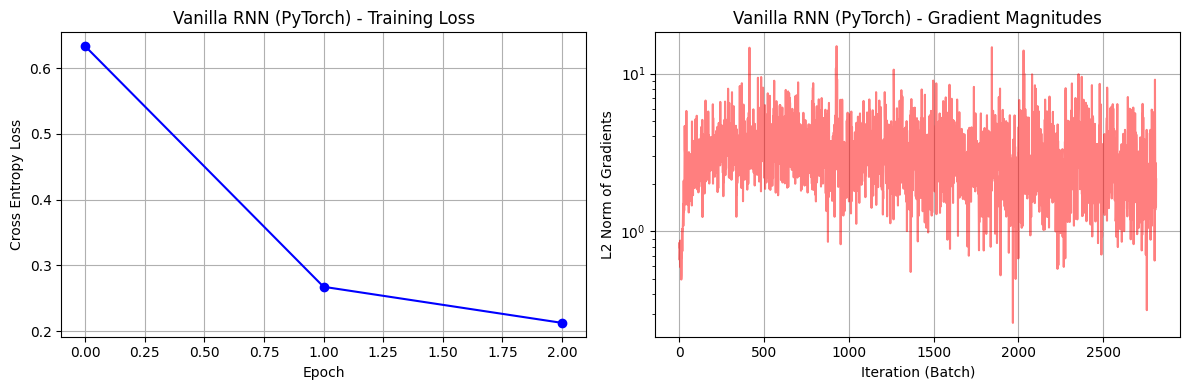


----------------------------------------
Training RNN From Scratch...
----------------------------------------
Epoch [1/3], Loss: 1.2557
Epoch [2/3], Loss: 0.7424
Epoch [3/3], Loss: 0.5414
Test Accuracy: 86.9%, Time: 42.81s, Params: 21386


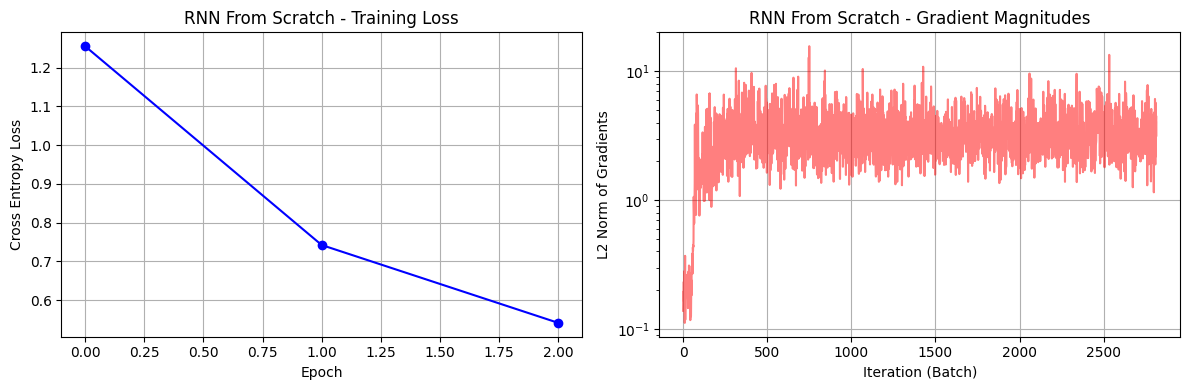


----------------------------------------
Training LSTM...
----------------------------------------
Epoch [1/3], Loss: 0.3650
Epoch [2/3], Loss: 0.0972
Epoch [3/3], Loss: 0.0671
Test Accuracy: 98.01%, Time: 66.59s, Params: 214282


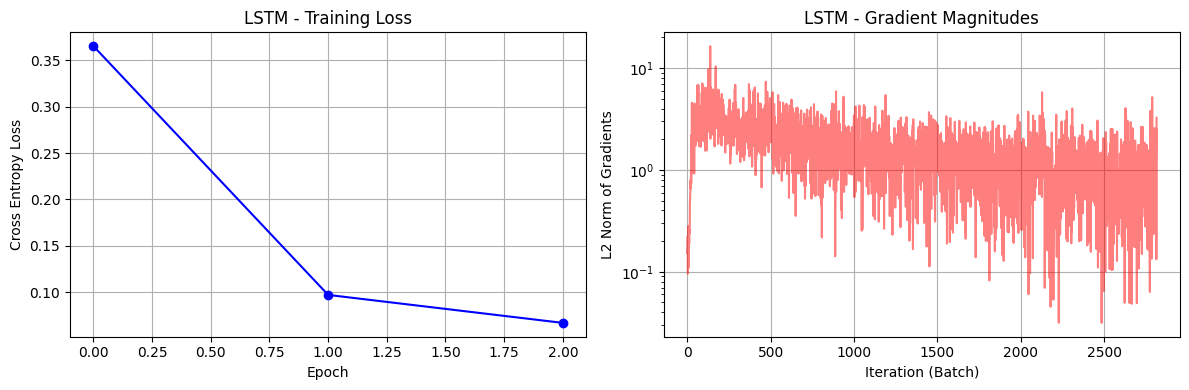


----------------------------------------
Training GRU...
----------------------------------------
Epoch [1/3], Loss: 0.3242
Epoch [2/3], Loss: 0.0761
Epoch [3/3], Loss: 0.0512
Test Accuracy: 98.47%, Time: 97.91s, Params: 161034


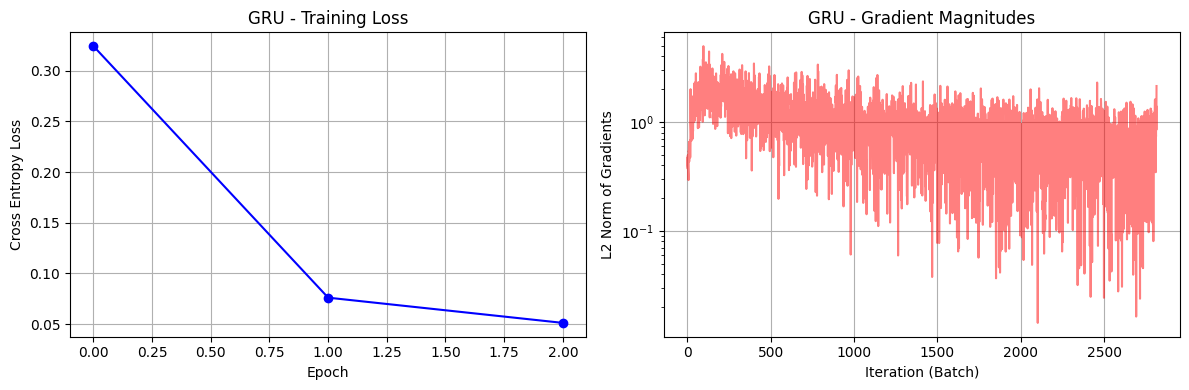


----------------------------------------
Training BiLSTM...
----------------------------------------
Epoch [1/3], Loss: 0.4210
Epoch [2/3], Loss: 0.1185
Epoch [3/3], Loss: 0.0793
Test Accuracy: 97.64%, Time: 69.35s, Params: 164362


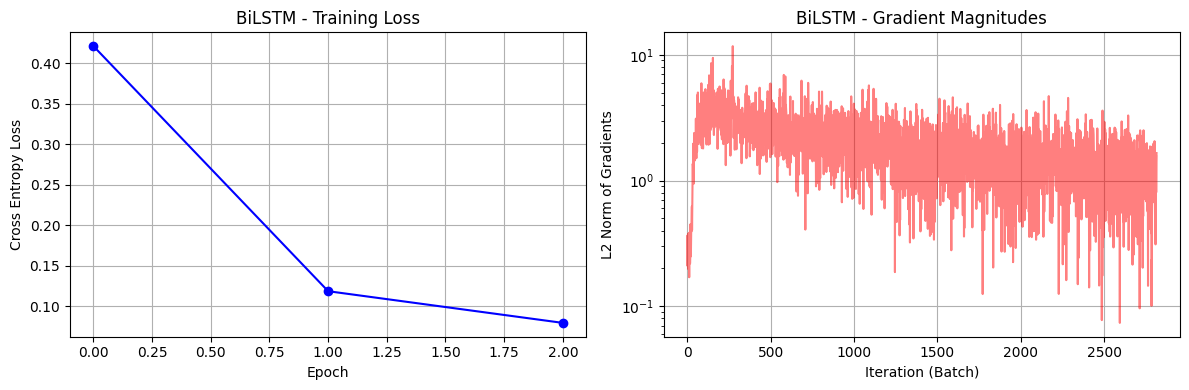


----------------------------------------
Training BiGRU...
----------------------------------------
Epoch [1/3], Loss: 0.5200
Epoch [2/3], Loss: 0.1336
Epoch [3/3], Loss: 0.0858
Test Accuracy: 98.09%, Time: 100.48s, Params: 123914


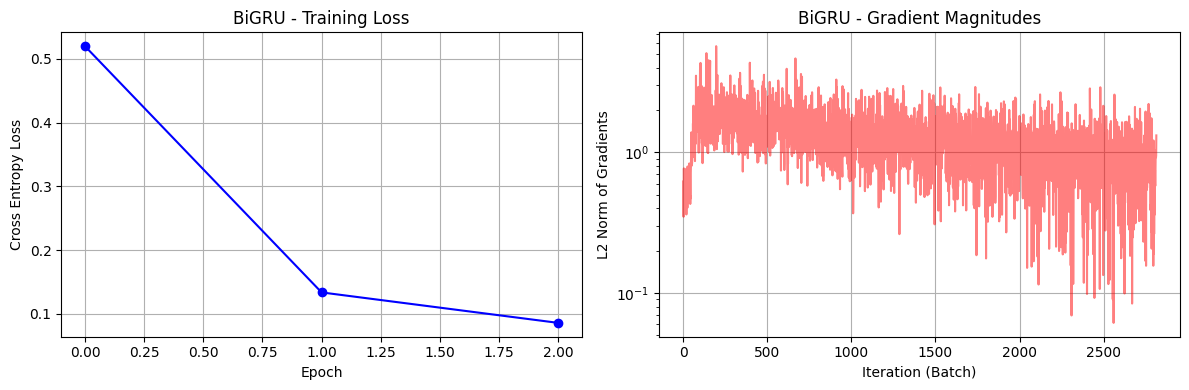


----------------------------------------
Training CNN+LSTM...
----------------------------------------
Epoch [1/3], Loss: 0.5242
Epoch [2/3], Loss: 0.1775
Epoch [3/3], Loss: 0.1282
Test Accuracy: 96.39%, Time: 66.02s, Params: 80458


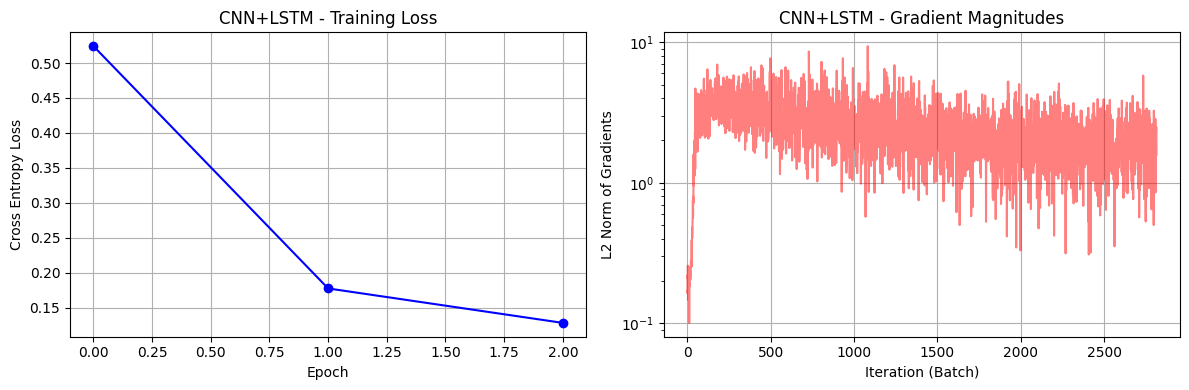


----------------------------------------
Training Time-Dist CNN+LSTM...
----------------------------------------
Epoch [1/3], Loss: 0.3609
Epoch [2/3], Loss: 0.0885
Epoch [3/3], Loss: 0.0622
Test Accuracy: 98.07%, Time: 64.49s, Params: 182602


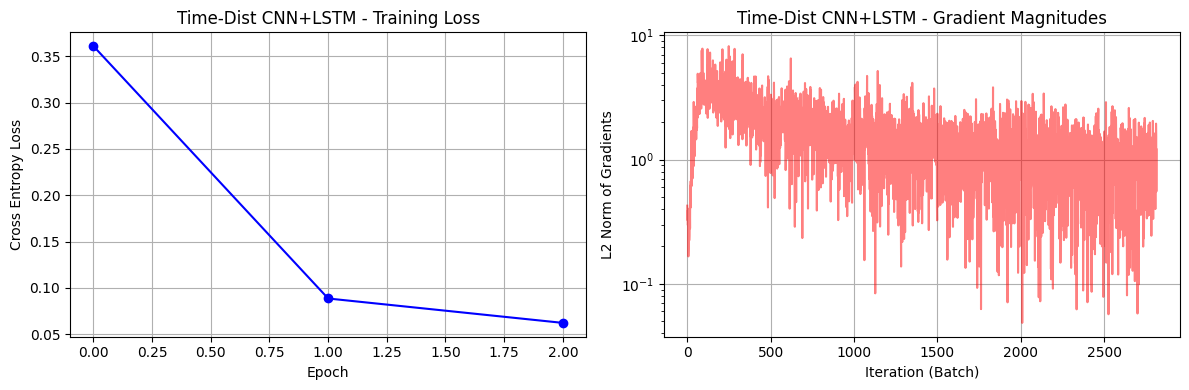


FINAL COMPARISON SUMMARY
Model                     | Accuracy (%)    | Time (s)   | Params
----------------------------------------------------------------------
Vanilla RNN (PyTorch)     | 93.64           | 72.13      | 54538
RNN From Scratch          | 86.90           | 42.81      | 21386
LSTM                      | 98.01           | 66.59      | 214282
GRU                       | 98.47           | 97.91      | 161034
BiLSTM                    | 97.64           | 69.35      | 164362
BiGRU                     | 98.09           | 100.48     | 123914
CNN+LSTM                  | 96.39           | 66.02      | 80458
Time-Dist CNN+LSTM        | 98.07           | 64.49      | 182602


In [15]:
import matplotlib.pyplot as plt

# Helper function to plot metrics instantly
def plot_metrics(model_name, losses, grads):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Training Loss [cite: 24, 96]
    axs[0].plot(losses, marker='o', color='b')
    axs[0].set_title(f'{model_name} - Training Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Cross Entropy Loss')
    axs[0].grid(True)
    
    # Plot Gradient Magnitudes for Vanishing Gradient Analysis [cite: 22]
    axs[1].plot(grads, color='r', alpha=0.5)
    axs[1].set_title(f'{model_name} - Gradient Magnitudes')
    axs[1].set_xlabel('Iteration (Batch)')
    axs[1].set_ylabel('L2 Norm of Gradients')
    axs[1].set_yscale('log') # Log scale is crucial for visualizing vanishing gradients
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Initialize ALL models
num_classes = 10 # MNIST [cite: 12]
models = {
    "Vanilla RNN (PyTorch)": VanillaRNN(input_size=28, hidden_size=128, num_layers=2, num_classes=num_classes).to(device),
    "RNN From Scratch": RNNFromScratch(input_size=28, hidden_size=128, num_classes=num_classes).to(device),
    "LSTM": LSTMModel(input_size=28, hidden_size=128, num_layers=2, num_classes=num_classes).to(device),
    "GRU": GRUModel(input_size=28, hidden_size=128, num_layers=2, num_classes=num_classes).to(device),
    "BiLSTM": BiLSTMModel(input_size=28, hidden_size=128, num_layers=1, num_classes=num_classes).to(device),
    "BiGRU": BiGRUModel(input_size=28, hidden_size=128, num_layers=1, num_classes=num_classes).to(device),
    "CNN+LSTM": CNNLSTMHybrid(hidden_size=128, num_layers=1, num_classes=num_classes).to(device),
    "Time-Dist CNN+LSTM": TimeDistributedCNNLSTM(hidden_size=128, num_layers=1, num_classes=num_classes).to(device)
}

results = {}

for name, model in models.items():
    print(f"\n{'-'*40}\nTraining {name}...\n{'-'*40}")
    
    # Using 3 epochs for quicker testing, but you can increase this!
    acc, t_time, losses, grads, params = train_and_evaluate(model, mnist_train_loader, mnist_test_loader, epochs=3)
    results[name] = {"Accuracy": acc, "Time (s)": t_time, "Params": params}
    
    print(f"Test Accuracy: {acc}%, Time: {t_time:.2f}s, Params: {params}")
    
    # Generate the plots immediately after training finishes
    plot_metrics(name, losses, grads)

# Print a nice markdown-friendly comparative table at the very end [cite: 87, 88]
print("\n" + "="*60)
print("FINAL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<25} | {'Accuracy (%)':<15} | {'Time (s)':<10} | {'Params'}")
print("-" * 70)
for name, metrics in results.items():
    print(f"{name:<25} | {metrics['Accuracy']:<15.2f} | {metrics['Time (s)']:<10.2f} | {metrics['Params']}")